In [38]:
from src.models.base_models import get_dummy_model, get_base_lasso, get_base_tree, get_base_xgboost
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from src.utils import DEV_SET_CLEAN_PATH, TARGET, print_model_metrics
from src.plots import plot_decision_tree, plot_feature_importance, plot_model_comparison
from src.pipeline import build_base_pipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Modelos base _sin_ preprocesamiento
Hacemos un preprocesamiento _muy_ básico para que los modelos puedan funcionar

In [39]:
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Pipeline Básico
Solo imputación & encoding

In [40]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

base_preprocessor = build_base_pipeline(numeric_cols, categorical_cols)

### 1.1 Dummy Regressor
Predice siempre la media

In [41]:
dummy = get_dummy_model()
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print_model_metrics(y_test, y_pred_dummy, "Dummy Regressor")

=== Modelo: Dummy Regressor ===
RMSE: 681152.9130
MAE: 125955.5544
R2: -0.0000
--------------------------------------------------


### 1.2. Lasso Regression
Requiere un pipeline básico para que pueda funcionar

In [42]:
lasso_model = get_base_lasso(base_preprocessor)

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print_model_metrics(y_test, y_pred_lasso, "Lasso")

=== Modelo: Lasso ===
RMSE: 678842.1587
MAE: 120393.1655
R2: 0.0068
--------------------------------------------------


### 1.3. Decision Tree

=== Modelo: Decision Tree ===
RMSE: 680648.2053
MAE: 118395.7571
R2: 0.0015
--------------------------------------------------


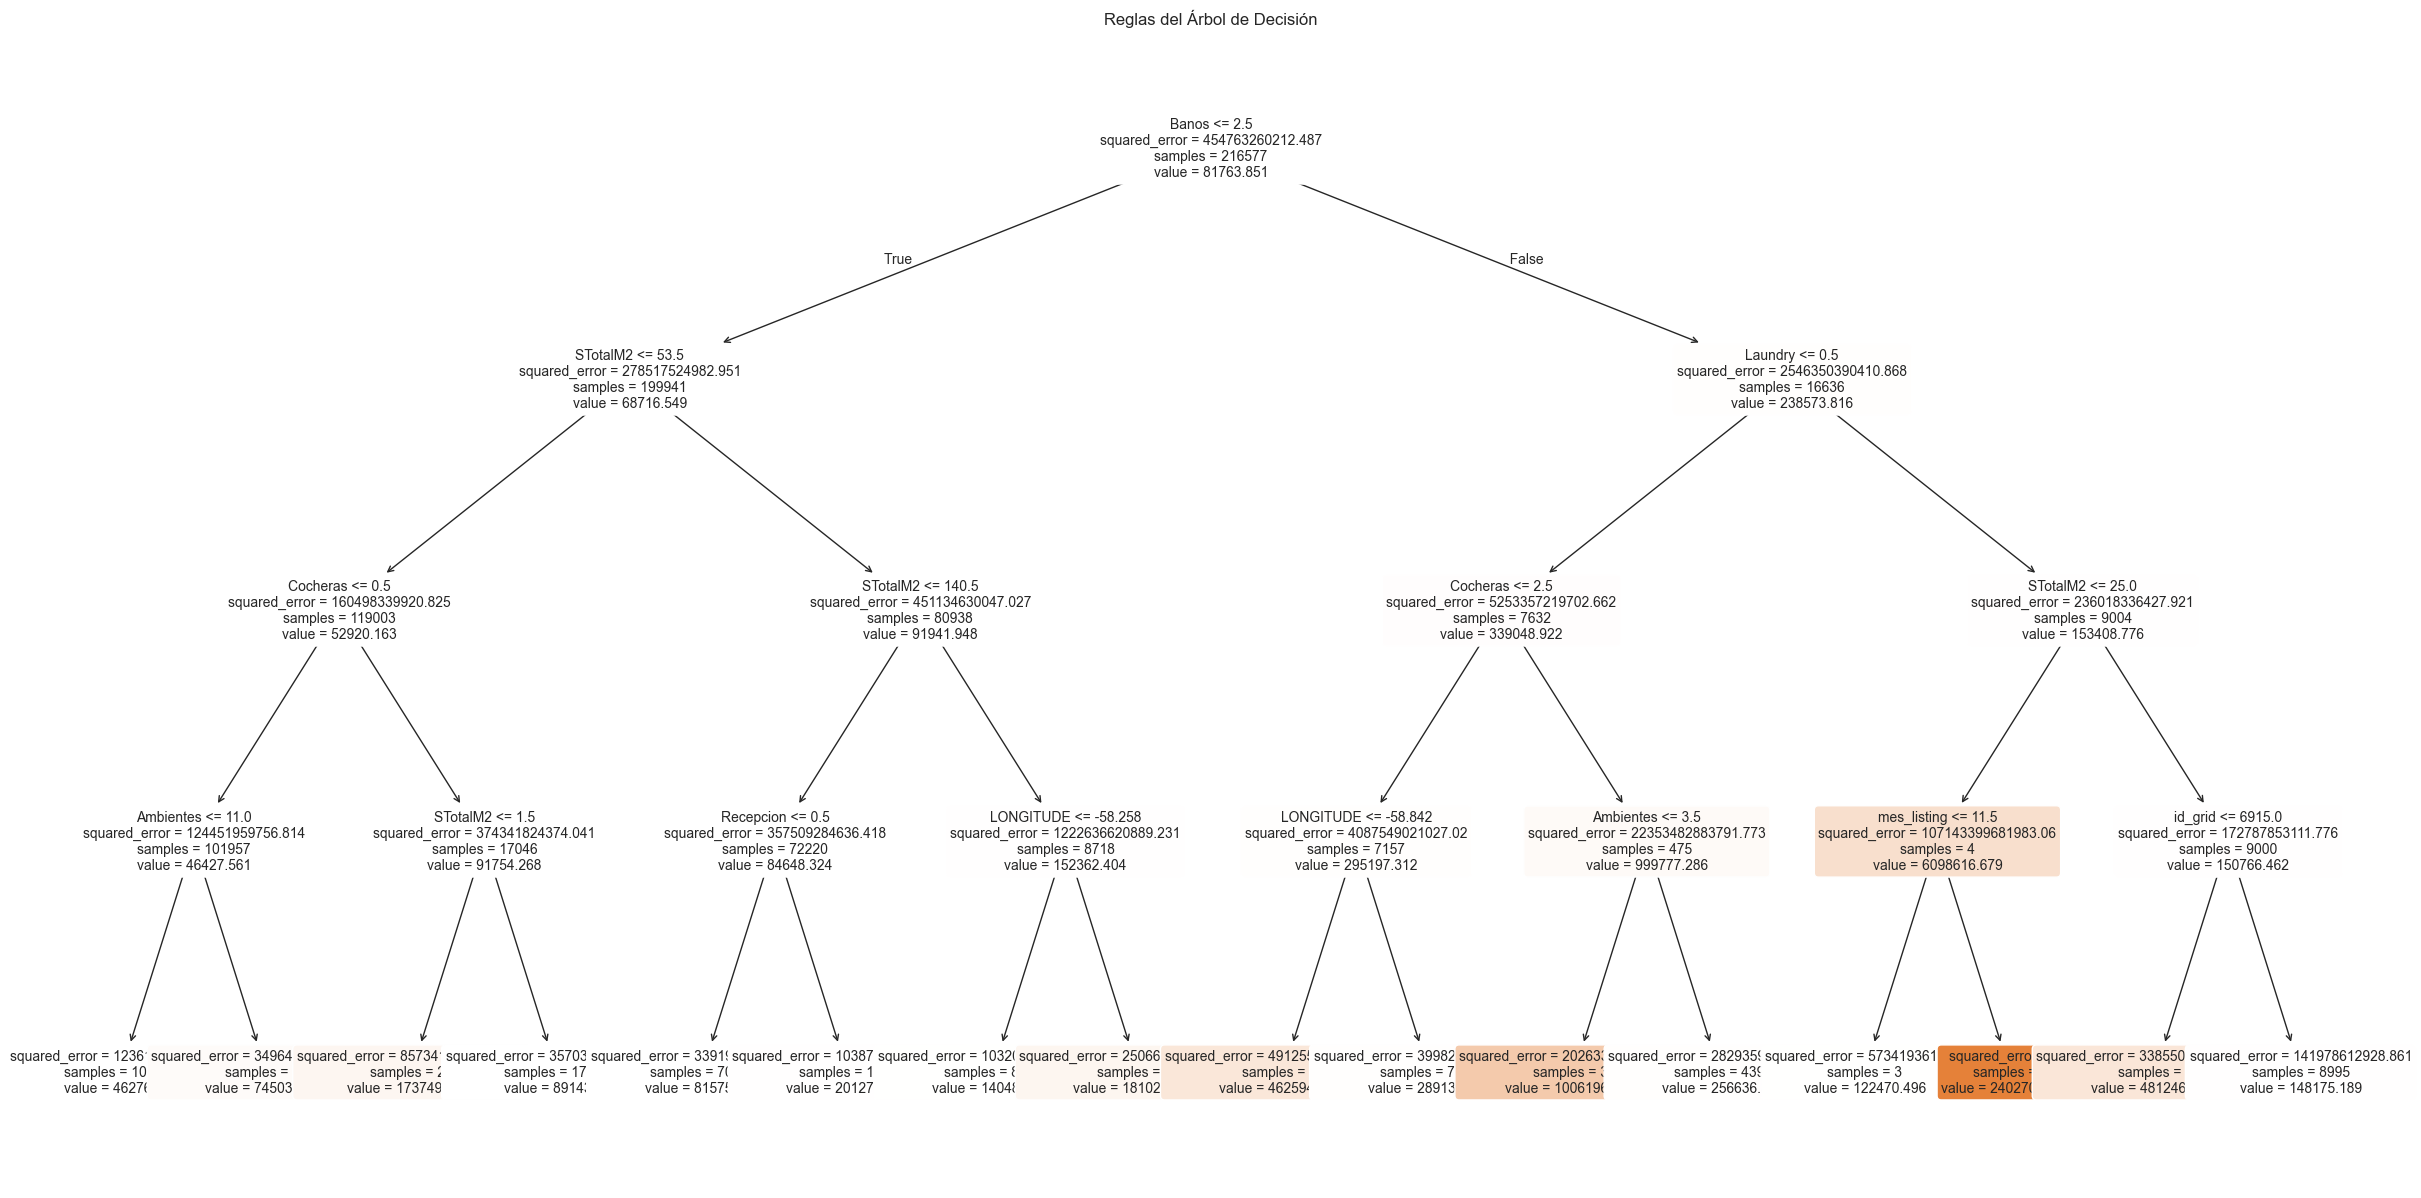

In [43]:
tree_model = get_base_tree(base_preprocessor)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print_model_metrics(y_test, y_pred_tree, "Decision Tree")
plot_decision_tree(tree_model, numeric_cols + categorical_cols, figsize=(30, 15))

### 1.4. XGBoost

In [44]:
xgb_model = get_base_xgboost(base_preprocessor)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print_model_metrics(y_test, y_pred_xgb, "XGBoost")

=== Modelo: XGBoost ===
RMSE: 449359.3652
MAE: 68698.6194
R2: 0.5648
--------------------------------------------------


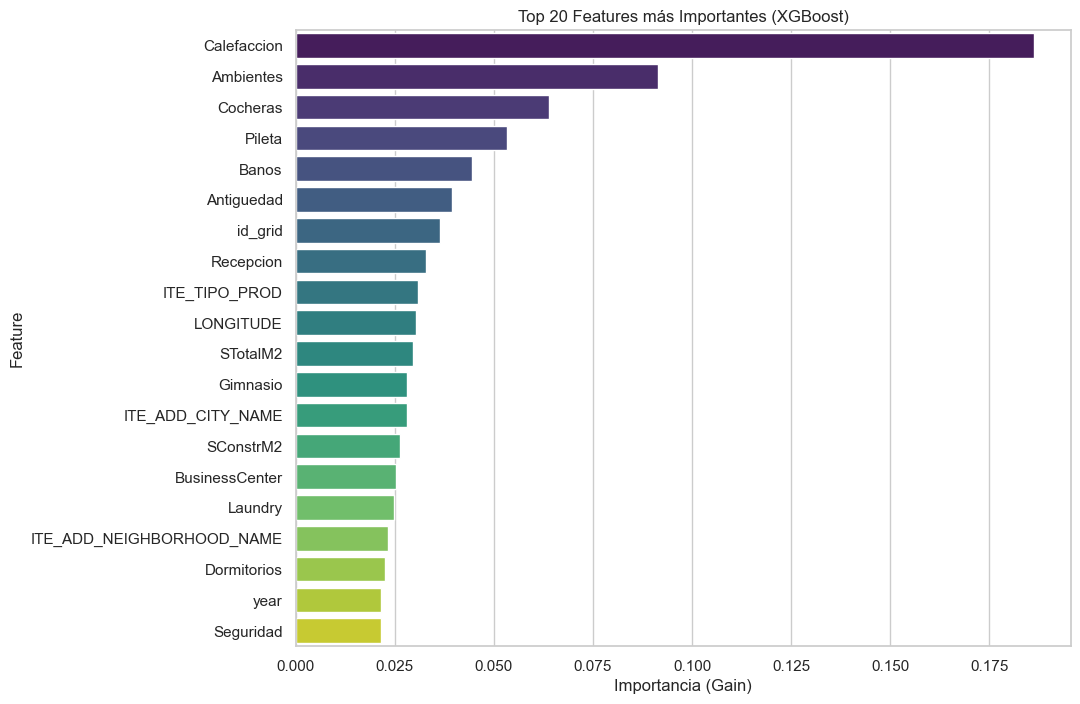

In [45]:
plot_feature_importance(xgb_model, numeric_cols + categorical_cols)

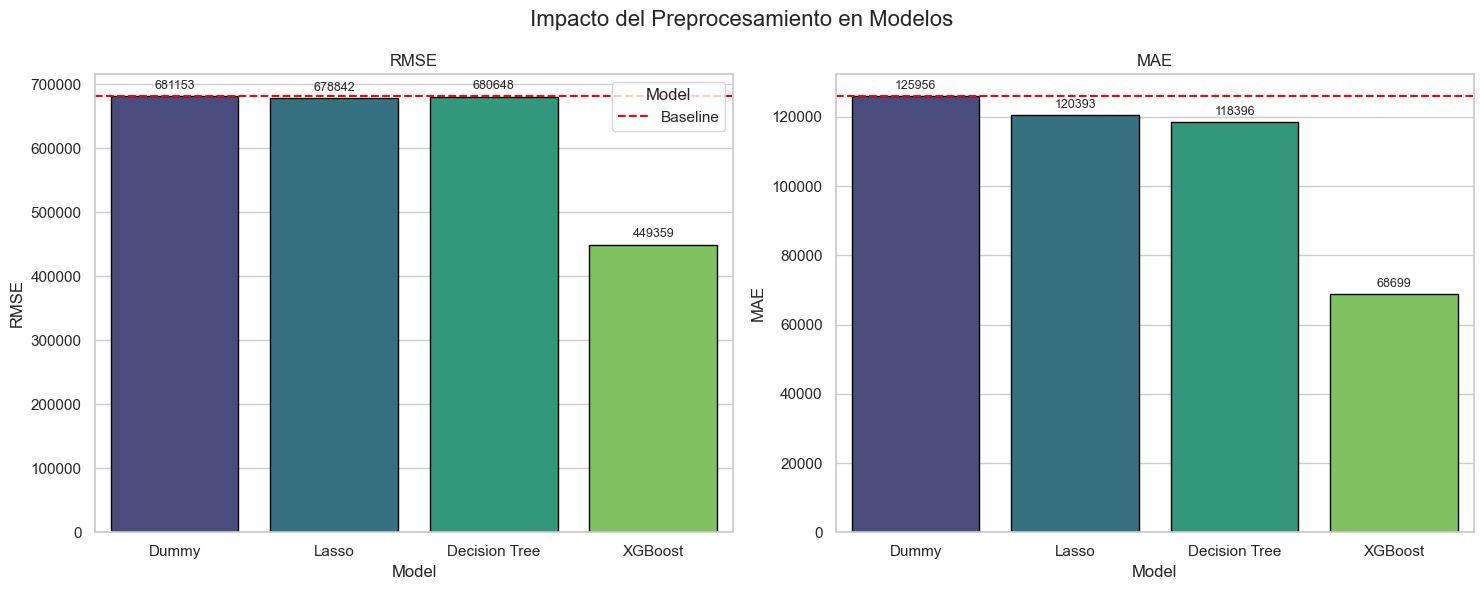

,Model,Variant,RMSE,MAE,R2,MAPE
0,Dummy,Raw,681152.912984,125955.554357,-0.000008,8.174219
1,Lasso,Raw,678842.158732,120393.165524,0.006765,6.573484
2,Decision Tree,Raw,680648.205261,118395.757090,0.001473,6.123546
3,XGBoost,Raw,449359.365182,68698.619403,0.564787,4.949633


In [46]:
models_predictions = {
    'model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'y_pred': [y_pred_dummy, y_pred_lasso, y_pred_tree, y_pred_xgb],
    'y_test': y_test,
}

plot_model_comparison(models_predictions)

In [47]:
# Nos guardamos las predicciones
df_base_preds = pd.DataFrame({
    'y_test': y_test,
    'Dummy': y_pred_dummy,
    'Lasso': y_pred_lasso,
    'Decision Tree': y_pred_tree,
    'XGBoost': y_pred_xgb
})
df_base_preds.to_csv('../predictions/base_models.csv', index=False)